# Smart ML System for Predictive Analysis of Student Performance

## 01 - Data Understanding

This notebook focuses on understanding the structure, quality, and characteristics of the student performance dataset before performing data cleaning, exploratory data analysis, feature engineering, and machine learning.

In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [11]:
file_path = Path("../data/raw/student_performance_analysis.xlsx")

df = pd.read_excel(
    file_path,
    sheet_name="Raw_Data"
)

df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade,Perfomance Category,attendence category,Study hours category,Participation level
0,1,18.5,95.6,3.8,97.9,A,Excellent,High,Medium Study,Low
1,2,14.0,80.0,2.5,83.9,B,Good,Medium,Medium Study,Low
2,3,19.5,86.3,5.3,100.0,A,Excellent,Medium,Medium Study,Medium
3,4,25.7,70.2,7.0,100.0,A,Excellent,Low,High Study,High
4,5,13.4,81.9,6.9,92.0,A,Excellent,Medium,Medium Study,Medium


In [12]:
df.shape

(5010, 10)

In [13]:
df.columns.tolist()

['student_id',
 'weekly_self_study_hours',
 'attendance_percentage',
 'class_participation',
 'total_score',
 'grade',
 'Perfomance Category',
 'attendence category',
 'Study hours category',
 'Participation level']

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5010 entries, 0 to 5009
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               5010 non-null   int64  
 1   weekly_self_study_hours  5010 non-null   float64
 2   attendance_percentage    5010 non-null   float64
 3   class_participation      5010 non-null   float64
 4   total_score              5010 non-null   float64
 5   grade                    5010 non-null   str    
 6   Perfomance Category      5010 non-null   str    
 7   attendence category      5010 non-null   str    
 8   Study hours category     5010 non-null   str    
 9   Participation level      5010 non-null   str    
dtypes: float64(4), int64(1), str(5)
memory usage: 391.5 KB


In [15]:
df.describe()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score
count,5010.000000,5010.000000,5010.000000,5010.000000,5010.000000
mean,2505.500000,15.075948,84.657984,5.992375,84.637166
std,1446.406755,6.867848,9.409866,1.964185,15.358746
min,1.000000,0.000000,50.000000,0.000000,14.600000
25%,1253.250000,10.400000,78.200000,4.700000,74.700000
50%,2505.500000,15.100000,84.650000,6.000000,88.050000
75%,3757.750000,19.700000,91.700000,7.400000,100.000000
max,5010.000000,40.000000,100.000000,10.000000,100.000000


In [16]:
df.isnull().sum()

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
Perfomance Category        0
attendence category        0
Study hours category       0
Participation level        0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.nunique()

student_id                 5010
weekly_self_study_hours     346
attendance_percentage       408
class_participation         100
total_score                 587
grade                         5
Perfomance Category           4
attendence category           3
Study hours category          3
Participation level           3
dtype: int64

In [19]:
categorical_columns = [
    "grade",
    "Perfomance Category",
    "attendence category",
    "Study hours category",
    "Participation level"
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


grade
<StringArray>
['A', 'B', 'C', 'D', 'F']
Length: 5, dtype: str

Perfomance Category
<StringArray>
['Excellent', 'Good', 'Average', 'Needs Improvement']
Length: 4, dtype: str

attendence category
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Study hours category
<StringArray>
['Medium Study', 'High Study', 'Low Study']
Length: 3, dtype: str

Participation level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str


In [20]:
df["total_score"].describe()

count    5010.000000
mean       84.637166
std        15.358746
min        14.600000
25%        74.700000
50%        88.050000
75%       100.000000
max       100.000000
Name: total_score, dtype: float64

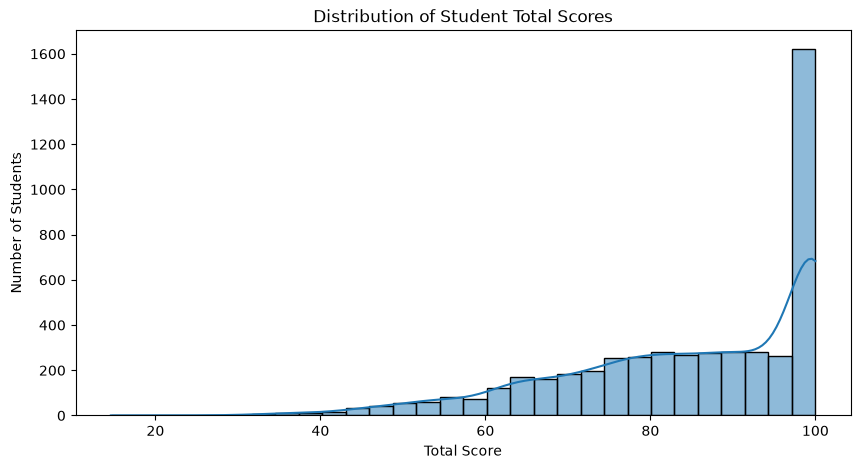

In [21]:
plt.figure(figsize=(10, 5))

sns.histplot(df["total_score"], bins=30, kde=True)

plt.title("Distribution of Student Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

### Target Variable Findings

The `total_score` variable ranges from 14.6 to 100, with a mean of 84.64 and a median of 88.05.

The distribution shows a strong concentration of students at the maximum score of 100, indicating a ceiling effect. The distribution is not symmetric, with fewer observations at the lower score range and a higher concentration toward the upper range.

This characteristic of the target variable should be considered during machine learning model development and evaluation.

In [22]:
numerical_columns = [
    "weekly_self_study_hours",
    "attendance_percentage",
    "class_participation",
    "total_score"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,weekly_self_study_hours,attendance_percentage,class_participation,total_score
weekly_self_study_hours,1.000000,-0.019163,-0.033600,0.809622
attendance_percentage,-0.019163,1.000000,-0.013619,-0.029022
class_participation,-0.033600,-0.013619,1.000000,-0.032842
total_score,0.809622,-0.029022,-0.032842,1.000000


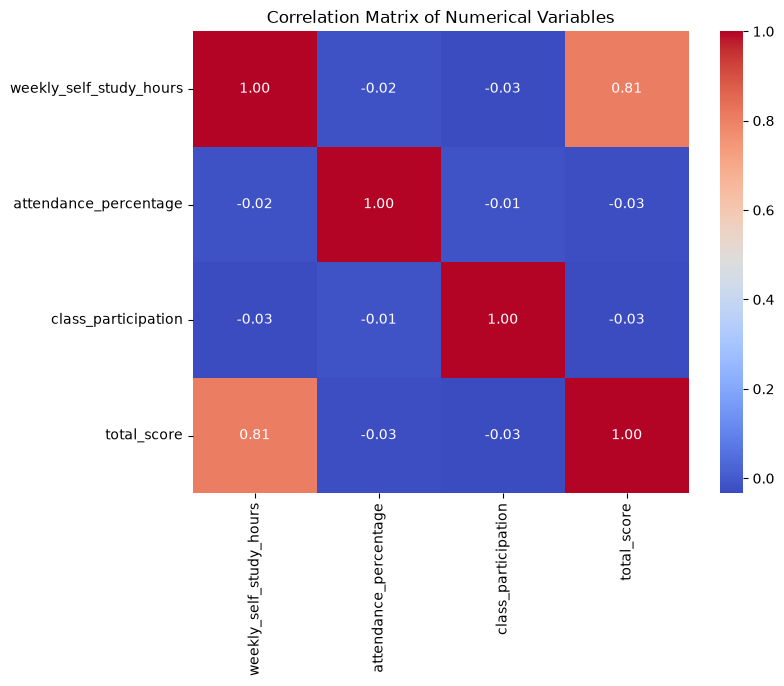

In [23]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

## 14. Initial Findings and Conclusion

### Dataset Quality
- The dataset contains 5,010 student records and 10 columns.
- No missing values were identified.
- No duplicate records were identified.
- The dataset contains numerical and categorical variables.

### Target Variable
- `total_score` is selected as the primary target variable for the predictive analysis.
- The average total score is 84.64, while the median is 88.05.
- Scores range from 14.6 to 100.
- The distribution shows a strong concentration at the maximum score of 100, indicating a ceiling effect.

### Feature Relationships
- `weekly_self_study_hours` has a strong positive correlation with `total_score` (r ≈ 0.81).
- `attendance_percentage` has a very weak linear correlation with `total_score` (r ≈ -0.03).
- `class_participation` has a very weak linear correlation with `total_score` (r ≈ -0.03).

### Categorical Variables
- `grade`, `Perfomance Category`, `attendence category`, `Study hours category`, and `Participation level` contain categorical information.
- Some categorical columns appear to be derived from numerical variables or the target variable and therefore require further investigation before being used as machine learning features.

### Conclusion
The dataset is structurally clean with no missing or duplicate records. Initial analysis indicates that weekly self-study hours has a strong linear relationship with total score, while attendance and class participation have weak linear relationships in this dataset.

Further data cleaning and exploratory analysis are required before selecting final features and training machine learning models. Potential data leakage from derived categorical variables must also be investigated.